# Credit Card Fraud Detection
### Kaggle Dataset — End-to-End ML Pipeline

This notebook covers the full pipeline for fraud detection: loading the data, some EDA to understand what we're working with, preprocessing, and then training three different classifiers to compare their performance.

**Dataset:** [Credit Card Fraud Detection — Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
**Features:** 28 PCA-transformed components (V1–V28) + Time, Amount, Class  
**Target:** `Class` — 0 for Normal, 1 for Fraud

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive,files
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


## Loading the Dataset

Reading in the CSV file. The dataset has ~284K transactions. Most columns (V1–V28) are already PCA-transformed so we don't see the raw features — only `Time`, `Amount`, and `Class` are in their original form.

In [ ]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Exploratory Data Analysis (EDA)

Let's get a feel for the data before touching any models.

In [ ]:
df.describe()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df.isnull().sum()


,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


### Class Distribution

Checking unique class values and counts. We already know this is going to be very imbalanced — just confirming by how much.

In [ ]:
df['Class'].unique()

array([0, 1])

In [ ]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
counts = df['Class'].value_counts()

percentage = df['Class'].value_counts(normalize=True)*100


summary_Table = pd.DataFrame({
    'Count': counts,
    'Percentage (%)': percentage.map('{:.2f}%'.format)
})
summary_Table
summary_Table.index = ['Normal (0)', 'Fraud (1)']


summary_Table


,Count,Percentage (%)
Normal (0),284315,99.83%
Fraud (1),492,0.17%


### Visualizing the Imbalance

Using log scale on the y-axis because the gap between Normal and Fraud is so large that a regular bar chart makes the fraud bar nearly invisible.

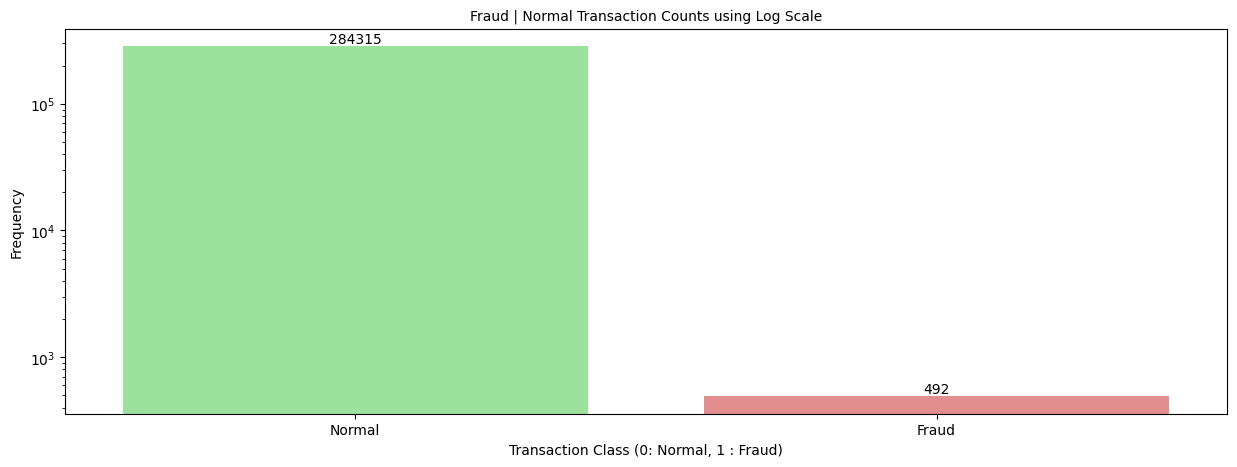

In [ ]:
colors = ['lightgreen','lightcoral']
plt.figure(figsize=(15,5))
sns.barplot(x=counts.index,y=counts.values,palette=colors)
plt.yscale('log')
plt.title(('Fraud | Normal Transaction Counts using Log Scale'),fontsize=10)
plt.xlabel('Transaction Class (0: Normal, 1 : Fraud)')
plt.ylabel('Frequency')
plt.xticks(ticks=[0, 1], labels=['Normal', 'Fraud'])
for i, count in enumerate(counts.values):
    plt.text(i, count, str(count), ha='center', va='bottom',fontsize=10)

plt.show()




In [ ]:
percentage = df['Class'].value_counts(normalize=True)*100


summary_Table = pd.DataFrame({
    'Count': counts,
    'Percentage (%)': percentage.map('{:.2f}%'.format)
})
summary_Table
summary_Table.index = ['Normal (0)', 'Fraud (1)']


summary_Table


,Count,Percentage (%)
Normal (0),284315,99.83%
Fraud (1),492,0.17%


### Class Imbalance in the Dataset
The dataset is highly imbalanced. Around 99.83% of the transactions are normal (284,315), while only 0.17% are fraudulent (492). This shows that fraudulent transactions are extremely rare compared to normal ones. Because of this imbalance, a machine learning model could achieve very high accuracy simply by predicting most transactions as normal. However, that would fail to detect actual fraud cases. Therefore, in fraud detection problems, it is important to use evaluation metrics such as precision, recall, and F1-score instead of relying only on accuracy.

### Transaction Amount Distribution — Normal vs Fraud

Comparing how transaction amounts are distributed across both classes. Fraud transactions tend to cluster at lower amounts, but there are some high-value outliers too.

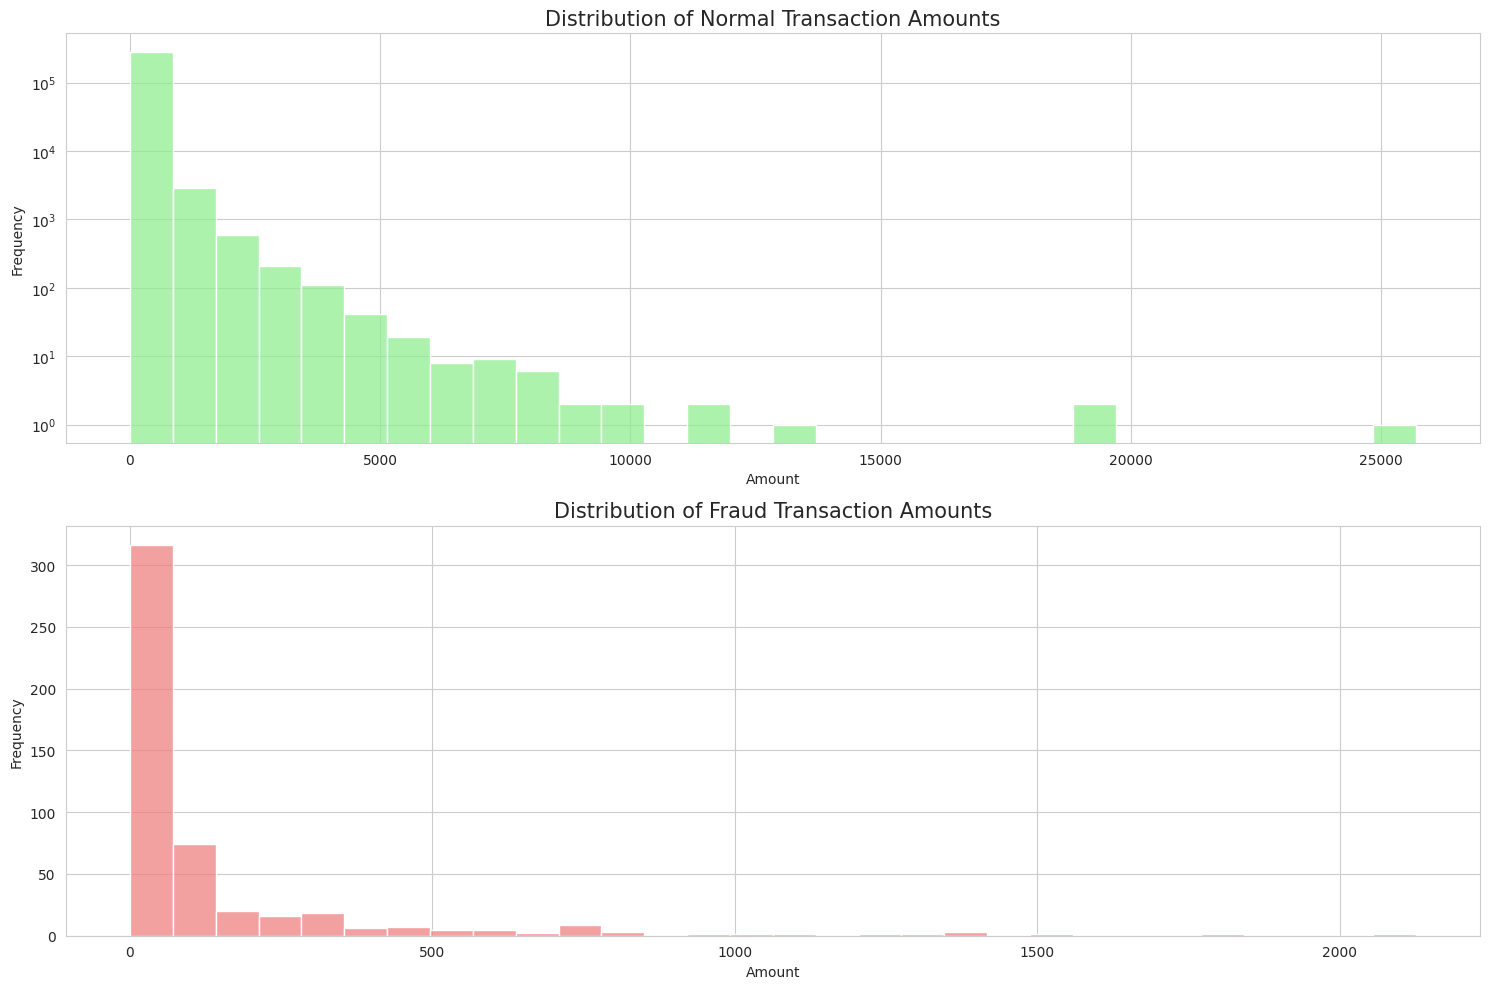

In [ ]:
sns.set_style('whitegrid')
fig, (ax1 ,ax2) = plt.subplots(2,1,figsize=(15,10))

# Creating Histogram for Normal Transaction

sns.histplot(df[df['Class']==0]["Amount"],bins=30, ax= ax1,color='lightgreen')
ax1.set_title("Distribution of Normal Transaction Amounts",fontsize=15)
ax1.set_yscale('log')
ax1.set_ylabel('Frequency')
ax1.set_xlabel('Amount')



# Creating Histogram for Fraud Transaction
sns.histplot(df[df['Class']==1]["Amount"],bins=30 ,ax = ax2 ,color='lightcoral')
ax2.set_title("Distribution of Fraud Transaction Amounts",fontsize=15)
ax2.set_ylabel('Frequency')
ax2.set_xlabel('Amount')
plt.tight_layout()
plt.show()


In [ ]:
df_fraud = df[df['Class']==1]
df_no_fraud = df[df['Class']==0]

print('Fraud_Describe is : ',df_fraud.describe())
print('No_Fraud_Describe is : ',df_no_fraud.describe())


Fraud_Describe is :                  Time          V1          V2          V3          V4  \
count     492.000000  492.000000  492.000000  492.000000  492.000000   
mean    80746.806911   -4.771948    3.623778   -7.033281    4.542029   
std     47835.365138    6.783687    4.291216    7.110937    2.873318   
min       406.000000  -30.552380   -8.402154  -31.103685   -1.313275   
25%     41241.500000   -6.036063    1.188226   -8.643489    2.373050   
50%     75568.500000   -2.342497    2.717869   -5.075257    4.177147   
75%    128483.000000   -0.419200    4.971257   -2.276185    6.348729   
max    170348.000000    2.132386   22.057729    2.250210   12.114672   

               V5          V6          V7          V8          V9  ...  \
count  492.000000  492.000000  492.000000  492.000000  492.000000  ...   
mean    -3.151225   -1.397737   -5.568731    0.570636   -2.581123  ...   
std      5.372468    1.858124    7.206773    6.797831    2.500896  ...   
min    -22.105532   -6.406267  -43

### Time vs Amount — Scatter Plot

Plotting each transaction against time and amount to see if fraud cases cluster at specific time windows or amount ranges.

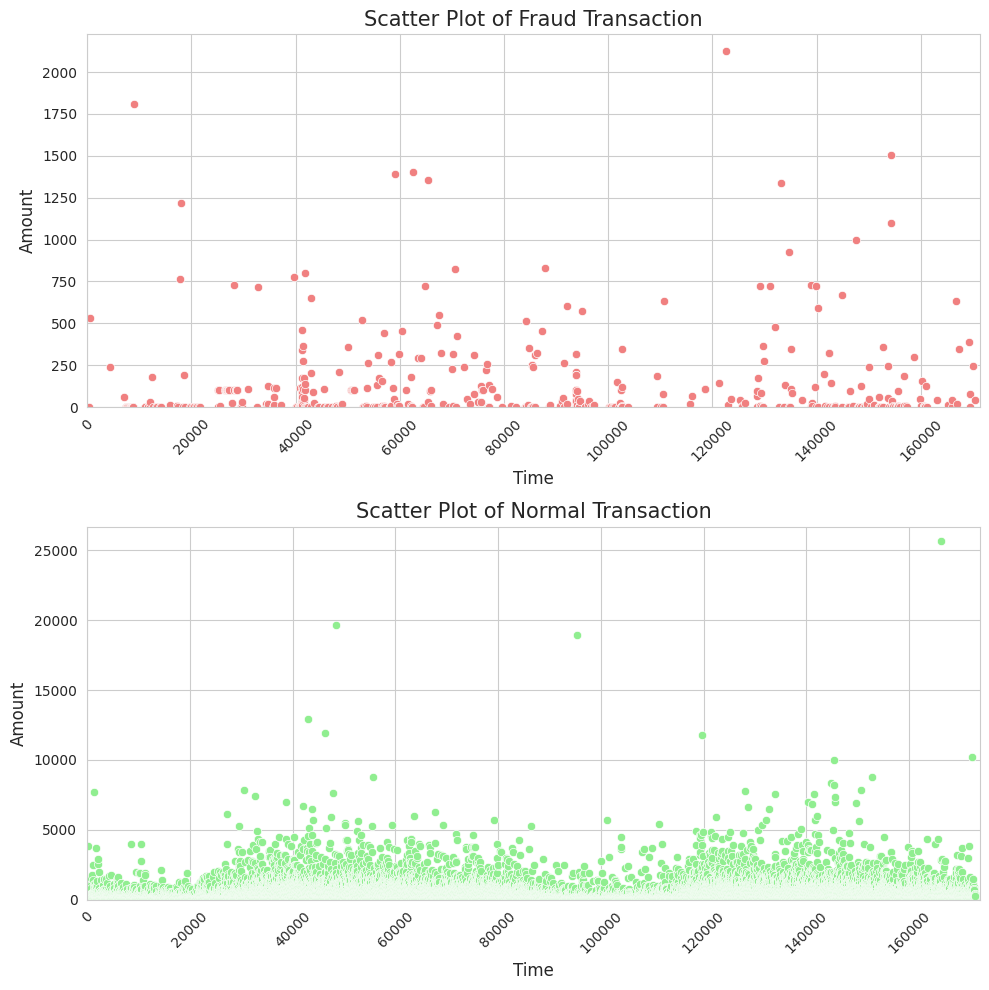

In [ ]:
# plt.figure(figsize=(10,5))
sns.set_style('whitegrid')
fig,(ax1,ax2) = plt.subplots(2,1,figsize=(10,10))

# Creating Scatter plot for Fraud Transaction
sns.scatterplot(data=df_fraud,x='Time',y='Amount',color='lightcoral',ax=ax1)
ax1.tick_params(axis='x',labelsize=10,rotation=45)
ax1.tick_params(axis='y',labelsize=10)

ax1.set_title('Scatter Plot of Fraud Transaction',fontsize=15)
ax1.set_xlabel('Time',fontsize=12)
ax1.set_ylabel('Amount',fontsize=12)
ax1.set_xlim([0,171348])
ax1.set_ylim([0,2225])


# Creating Scatter plot for Normal Transaction
sns.scatterplot(data=df_no_fraud,x='Time',y='Amount',color='lightgreen',ax=ax2)
ax2.tick_params(axis='x',labelsize=10,rotation=45)
ax2.tick_params(axis='y',labelsize=10)

ax2.set_title('Scatter Plot of Normal Transaction',fontsize=15)
ax2.set_xlabel('Time',fontsize=12)
ax2.set_ylabel('Amount',fontsize=12)
ax2.set_xlim([0,173792])
ax2.set_ylim([0,26691])







plt.tight_layout()
plt.show()


### High-Value Fraud Transactions

Checking how many fraud cases involve amounts greater than 500. The answer might be surprising — most fraud actually happens at lower amounts.

In [ ]:
big_fraud_num = df_fraud[df_fraud['Amount']>500].shape[0]
print('There are only {} frauds where the amount was bigger than 500 over {} frauds'.format(str(big_fraud_num),str(df_fraud.shape[0]) ))


There are only 35 frauds where the amount was bigger than 500 over 492 frauds


In [ ]:
print('Normal avg amount:', df[df['Class']==0]['Amount'].mean())
print('Fraud avg amount:', df[df['Class']==1]['Amount'].mean())
print('Fraud max amount:', df[df['Class']==1]['Amount'].max())

Normal avg amount: 88.29102242231328
Fraud avg amount: 122.21132113821139
Fraud max amount: 2125.87


In [ ]:
df[df['Class']==1]['Amount'].mean()


np.float64(122.21132113821139)

### Outlier Detection — IQR Method

Using the Interquartile Range to flag extreme `Amount` values. Important note: we're **not removing these outliers** — in fraud detection, unusual transaction amounts can carry real signal, so we scale them instead of dropping them.

In [ ]:
df['Amount'].sort_values()

Q1 = df['Amount'].quantile(0.25)
Q2 = df['Amount'].quantile(0.5)
Q3 = df['Amount'].quantile(0.75)

In [ ]:
IQR = Q3 - Q1
IQR

Lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_outliers = df[(df['Amount']< Lower_bound) | (df['Amount']> upper_bound)]
df_outliers

print(df_outliers.shape[0])

31904


In [ ]:
df_outliers['Class'].value_counts()

,count
Class,
0,31813
1,91


In [ ]:
outlier_percentage  = df_outliers['Class'].value_counts(normalize=True) * 100

outlier_summary_table = pd.DataFrame({
    'Count': df_outliers['Class'].value_counts(),
    'Percentage (%)': outlier_percentage.map('{:.2f}%'.format)
})

outlier_summary_table
outlier_summary_table.index = ['Normal (0)','Fraud (1)']
outlier_summary_table



,Count,Percentage (%)
Normal (0),31813,99.71%
Fraud (1),91,0.29%


### Dataset Overview

The dataset contains **284,807 transactions** with **31 features**. Among these transactions, **284,315 are normal transactions** and **492 are fraudulent transactions**.

This means that fraudulent transactions represent only **0.17% of the dataset**, while **99.83% of the transactions are legitimate**. This clearly shows that the dataset is **highly imbalanced**, which is a common challenge in fraud detection problems.

### Transaction Amount Distribution

The transaction amount shows a wide range of values. The **average transaction amount is about 88.35**, while the **maximum transaction amount reaches 25,691.16**.

Most transactions involve relatively small amounts. For example:

* 25% of the transactions are below **5.60**
* 50% of the transactions are below **22**
* 75% of the transactions are below **77.17**

This indicates that the majority of transactions are small, while only a few transactions involve very large amounts.

### Outlier Detection

To identify extreme values in transaction amounts, the **Interquartile Range (IQR)** method was used. Based on this approach, **31,904 transactions were identified as potential outliers**.

These outliers represent approximately **11.20% of the entire dataset**, which suggests that a noticeable portion of transactions have unusually large amounts compared to the typical range.

Looking at the statistics of the outlier transactions:

* Average outlier amount: **511.45**
* Minimum outlier amount: **184.52**
* Maximum outlier amount: **25,691.16**

This confirms that most outliers correspond to **high-value transactions**.

### Fraud within Outliers

Among the **31,904 outlier transactions**, only **91 transactions are fraudulent**, while **31,813 are normal transactions**.

This means that even though outliers represent unusually large transaction amounts, **most of them are still legitimate transactions**. Fraudulent transactions account for only **0.28% of the outlier group**.

### Fraud vs Transaction Amount

Further analysis shows that only **35 fraudulent transactions involve amounts greater than 500**, out of a total of **492 fraud cases**.

This indicates that fraud is **not limited to very large transaction amounts** and can also occur in relatively smaller transactions.

Additional statistics show that:

* The **maximum fraudulent transaction amount** is **2125.87**
* The **average fraudulent transaction amount** is **122.21**
* The **average normal transaction amount** is **88.29**

This suggests that fraudulent transactions tend to be slightly larger on average, but they are **not always extremely high-value transactions**.

### Outlier Handling Decision

Although many outliers were detected, they were **not removed from the dataset**. In fraud detection problems, unusual or extreme transaction values can represent suspicious activity. Removing these values could eliminate important patterns that help machine learning models detect fraud.

Instead of removing them, the **transaction amount will be scaled during preprocessing** so that machine learning models are not overly influenced by large values while still keeping the important information in the data.


### Fraud Activity by Hour of Day

Converting the `Time` column (seconds since first transaction) to hour of day. Want to see if fraudsters tend to operate at specific hours — could be a useful feature.

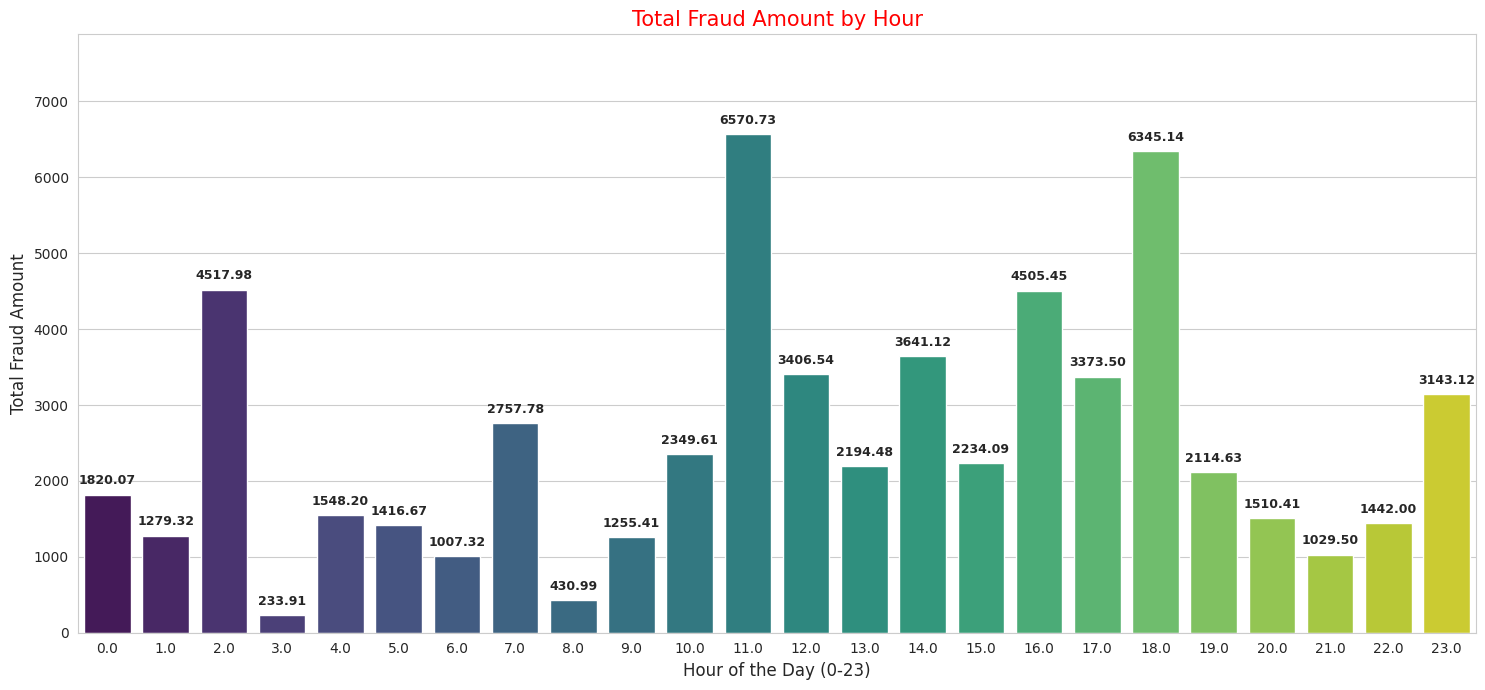

In [ ]:
df_fraud['Hour'] = (df_fraud['Time'] // 3600) % 24
fraud_amount_per_hour = df_fraud.groupby('Hour')['Amount'].sum().reset_index()


fig, ax3 = plt.subplots(figsize=(15, 7)) # 12,6 aspect ratio distribution ke liye better hota hai
ax = sns.barplot(data=fraud_amount_per_hour, x='Hour', y='Amount',palette='viridis', ax=ax3)

for i in ax.patches:
    ax.annotate(f'{i.get_height():.2f}', # .2f se exact decimal points dikhenge
                (i.get_x() + i.get_width() / 2., i.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 10),
                textcoords = 'offset points',
                fontsize=9, fontweight='bold')

ax3.tick_params(axis='x', labelsize=10,color='red')
ax3.tick_params(axis='y', labelsize=10)
ax3.set_title('Total Fraud Amount by Hour', fontsize=15,color='red')
ax3.set_xlabel('Hour of the Day (0-23)', fontsize=12)
ax3.set_ylabel('Total Fraud Amount', fontsize=12) # 'Amount' ki jagah 'Count'
plt.ylim(0, fraud_amount_per_hour['Amount'].max() * 1.2)

plt.tight_layout()
plt.show()

### Feature Correlation Heatmap

Quick correlation check across all features. Since V1–V28 are PCA-derived, we don't expect high multicollinearity there — mainly checking if `Amount` or `Time` correlate strongly with `Class`.

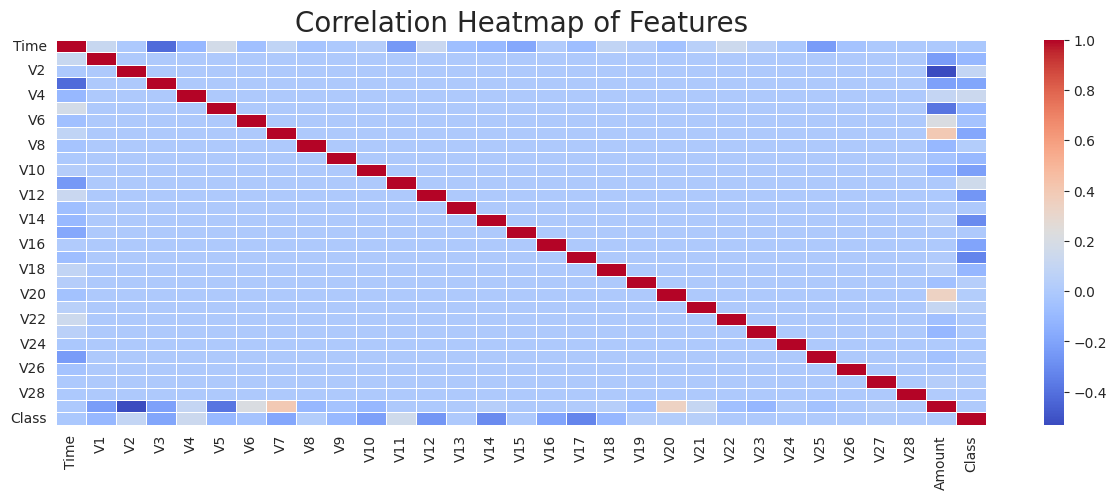

In [ ]:
corr_matrix = df.corr()

plt.figure(figsize=(15, 5))

sns.heatmap(corr_matrix,
            annot=False,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)

plt.title('Correlation Heatmap of Features', fontsize=20)
plt.show()

---

## Machine Learning

Now for the modelling part. We'll test three approaches:
- **Logistic Regression** — simple baseline
- **XGBoost** — gradient boosting with class weighting
- **Random Forest** — tested in multiple configurations

Since this is a highly imbalanced dataset, we focus on **Recall** and **F1-score** rather than plain accuracy.

In [ ]:
# ML imports
from imblearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import joblib

### Feature Engineering

Adding an `Hour` feature derived from the `Time` column. Captures time-of-day patterns that the raw seconds value wouldn't represent well.

In [ ]:
df['Hour'] = (df['Time'] // 3600) % 24


### Defining Features and Target

Dropping `Class` (that's our target) and `Time` (already converted to `Hour`) from the feature matrix.

In [ ]:
X = df.drop(['Class','Time'],axis=1)
y = df['Class']


### Train-Test Split

67% training, 33% test. Using `stratify=y` so the fraud/normal ratio stays consistent in both splits.

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.33,random_state=42,stratify=y
)

### Feature Scaling — RobustScaler

Scaling the `Amount` column using `RobustScaler`. It's more resistant to outliers than `StandardScaler` since it uses median and IQR instead of mean and std. Fitting only on training data, then transforming the test set.

In [ ]:
scaler = RobustScaler()
X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test['Amount'] = scaler.transform(X_test[['Amount']])

### Handling Class Imbalance — SMOTE

With only ~0.17% fraud cases, the model would just learn to predict Normal for everything and still get 99.8% accuracy. SMOTE (Synthetic Minority Oversampling Technique) generates synthetic fraud samples to balance the training set.

> **Important:** SMOTE is applied only on the **training data**. The test set stays untouched.

In [ ]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

model = RandomForestClassifier(random_state=42)
model.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(random_state=42)

---

### Model 1 — Logistic Regression (Baseline)

Simple baseline model. GridSearchCV is used to find the best regularization parameters. Optimizing for **Recall** because missing a real fraud is much more costly than a false alarm.

In [ ]:
# trying different C values and penalties to see what sticks
param_grid = {
    'C' : [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

print("Running GridSearchCV...")
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='recall'
)
grid_search.fit(X_train_resampled, y_train_resampled)
print(f"Best params: {grid_search.best_params_}")

# training with best params found above
LR_model = LogisticRegression(
    C=10,
    penalty='l2',
    solver='liblinear',
    max_iter=1000,
    random_state=42
)
LR_model.fit(X_train_resampled, y_train_resampled)

joblib.dump(LR_model, 'lr_baseline.pkl')
print("model saved lr_baseline.pkl")

predictions = LR_model.predict(X_test)
acc = accuracy_score(y_test, predictions)

print(f'\nLogistic Regression Results')
print(f'Accuracy: {acc * 100:.2f}%')
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Running GridSearchCV...
Best params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
model saved → lr_baseline.pkl

Logistic Regression Results
Accuracy: 97.66%

Confusion Matrix:
[[91648  2177]
 [   18   144]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     93825
           1       0.06      0.89      0.12       162

    accuracy                           0.98     93987
   macro avg       0.53      0.93      0.55     93987
weighted avg       1.00      0.98      0.99     93987



---

### Model 2 — XGBoost

XGBoost with `scale_pos_weight=500` to put extra emphasis on the minority (Fraud) class. This is an alternative to SMOTE for handling imbalance — here we use both together.

In [ ]:
xgb_comparison_model = XGBClassifier(
    subsample=0.8,
    scale_pos_weight=500,   # heavy weight on fraud class for better recall
    n_estimators=150,
    max_depth=3,
    learning_rate=0.2,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)

print("Training XGBoost...")
xgb_comparison_model.fit(X_train_resampled, y_train_resampled)

joblib.dump(xgb_comparison_model, 'xgb_fraud.pkl')
print("model saved  xgb_fraud.pkl")

xgb_predictions = xgb_comparison_model.predict(X_test)
cm_xgb = confusion_matrix(y_test, xgb_predictions)

print("\nXGBoost Results")
print("Confusion Matrix:")
print(cm_xgb)
print("\nClassification Report:")
print(classification_report(y_test, xgb_predictions))
print(f"\nFrauds caught: {cm_xgb[1,1]} | False alarms: {cm_xgb[0,1]}")

Training XGBoost...
model saved → xgb_fraud.pkl

XGBoost Results
Confusion Matrix:
[[92005  1820]
 [   16   146]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     93825
           1       0.07      0.90      0.14       162

    accuracy                           0.98     93987
   macro avg       0.54      0.94      0.56     93987
weighted avg       1.00      0.98      0.99     93987


Frauds caught: 146 | False alarms: 1820


---

### Model 3 — Random Forest (Multiple Versions)

Testing RF in stages to see how much each step improves performance:
- **3(i):** Baseline RF on raw imbalanced data
- **3(ii):** RF on SMOTE-resampled data (no hyperparameter tuning)
- **3(iii):** RF with best hyperparameters on SMOTE data

In [ ]:
# plain RF on raw imbalanced data — just to see where we start
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

print("Training RF baseline...")
rf_model.fit(X_train, y_train)

joblib.dump(rf_model, 'rf_baseline.pkl')
print("model saved rf_baseline.pkl")

rf_predictions = rf_model.predict(X_test)

print("\nRF Baseline Results")
print(confusion_matrix(y_test, rf_predictions))
print(classification_report(y_test, rf_predictions))

Training RF baseline...
model saved → rf_baseline.pkl

RF Baseline Results
[[93820     5]
 [   38   124]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     93825
           1       0.96      0.77      0.85       162

    accuracy                           1.00     93987
   macro avg       0.98      0.88      0.93     93987
weighted avg       1.00      1.00      1.00     93987



In [ ]:
# RF on SMOTE-balanced data, no tuning — checking how much just balancing helps
rf_resampled_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

print("Training RF on resampled data...")
rf_resampled_model.fit(X_train_resampled, y_train_resampled)

joblib.dump(rf_resampled_model, 'rf_smote_notuning.pkl')
print("model saved rf_smote_notuning.pkl")

rf_resampled_preds = rf_resampled_model.predict(X_test)

print("\nRF + SMOTE (no tuning) Results")
print(confusion_matrix(y_test, rf_resampled_preds))
print(classification_report(y_test, rf_resampled_preds))

Training RF on resampled data...
model saved → rf_smote_notuning.pkl

RF + SMOTE (no tuning) Results
[[93674   151]
 [   28   134]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     93825
           1       0.47      0.83      0.60       162

    accuracy                           1.00     93987
   macro avg       0.73      0.91      0.80     93987
weighted avg       1.00      1.00      1.00     93987



In [ ]:
# RF with best params from GridSearch
final_rf_model = RandomForestClassifier(
    n_estimators=150,
    min_samples_split=2,
    max_features='log2',
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

print("Training tuned RF...")
final_rf_model.fit(X_train_resampled, y_train_resampled)

joblib.dump(final_rf_model, 'rf_tuned_smote.pkl')
print("model saved rf_tuned_smote.pkl")

y_pred = final_rf_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Training tuned RF...
model saved → rf_tuned_smote.pkl
[[93794    31]
 [   33   129]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     93825
           1       0.81      0.80      0.80       162

    accuracy                           1.00     93987
   macro avg       0.90      0.90      0.90     93987
weighted avg       1.00      1.00      1.00     93987



“I selected Model 3 because in fraud detection the cost of a false negative is much higher than a false positive. A missed fraud transaction can directly cause financial loss, customer dissatisfaction, chargeback cost, and reputational damage. Although Model 3 increases false positives, those cases can be manually reviewed or sent to a secondary verification layer. Therefore, from a risk-management perspective, higher recall is preferred.”

### Model 3(iv) — Final RF with Custom Decision Threshold

Lowering the decision threshold from 0.5 to **0.35** so the model flags more transactions as fraud. This increases recall at the cost of some precision — which is the right tradeoff here since a missed fraud is far worse than a false alarm that gets manually reviewed.

In [ ]:
# same model as 3(iii) but with a custom threshold — this is the one we're going with
final_rf_model = RandomForestClassifier(
    n_estimators=150,
    min_samples_split=2,
    max_features='log2',
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

print("Training... give it a minute")
final_rf_model.fit(X_train_resampled, y_train_resampled)

joblib.dump(final_rf_model, 'fraud_detector_final.pkl')
print("model saved fraud_detector_final.pkl  is best model")

# predict_proba gives probabilities — we lower the threshold from 0.5 to 0.35
# so the model is more aggressive about flagging fraud (higher recall)
y_probs = final_rf_model.predict_proba(X_test)[:, 1]
best_threshold = 0.35
y_pred_custom = (y_probs >= best_threshold).astype(int)

print(f"\nResults with {best_threshold} threshold")
print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))

cm = confusion_matrix(y_test, y_pred_custom)
print(f"\nFrauds caught: {cm[1,1]} | Missed: {cm[1,0]} | False alarms: {cm[0,1]}")

Training... give it a minute
model saved → fraud_detector_final.pkl  ← best model

Results with 0.35 threshold
[[93775    50]
 [   25   137]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     93825
           1       0.73      0.85      0.79       162

    accuracy                           1.00     93987
   macro avg       0.87      0.92      0.89     93987
weighted avg       1.00      1.00      1.00     93987


Frauds caught: 137 | Missed: 25 | False alarms: 50
